# Laboratorio 9 – Redes Neuronales Artificiales (RNA)

## Configuración – Reproducción del Pipeline de Labs 4–8

In [43]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score, mean_squared_error, mean_absolute_error,
                             r2_score)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.svm import SVC, SVR, LinearSVC

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [44]:
# Pipeline idéntico a Labs 4–8
result  = pyreadr.read_r('listings.Rdata')
df_raw  = result[list(result.keys())[0]].copy()
df      = df_raw.copy()

# Precio
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]', '', regex=True)
                               .str.strip().replace('', np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

# Eliminar columnas innecesarias
cols_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Eliminar columnas con >60% nulos
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

# Feature engineering de fechas
if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

# Booleans → 0/1
for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})

# Porcentajes
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding de variables categóricas
TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features  = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                               'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')

df_encoded = pd.get_dummies(df[num_features + cat_features + [TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# Variable respuesta categórica
p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)
df_encoded['price_category'] = df_encoded[TARGET].apply(
    lambda p: 'Económico' if p <= p33 else ('Intermedio' if p <= p67 else 'Caro'))

feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'price_category']]
X        = df_encoded[feature_cols]
y_price  = df_encoded[TARGET]

# Splits IDÉNTICOS a todos los labs anteriores
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X, y_price, test_size=0.20, random_state=42)

le = LabelEncoder()
y_cat = le.fit_transform(df_encoded['price_category'])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.20, random_state=42, stratify=y_cat)

print(f"Dataset final: {df_encoded.shape[0]:,} filas x {len(feature_cols)} features")
print(f"Train completo: {len(X_train):,}  |  Test completo: {len(X_test):,}")
print(f"Umbral P33 = ${p33:.0f}  |  Umbral P67 = ${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline reproducido — idéntico a Labs 4-8.")

Dataset final: 75,531 filas x 75 features
Train completo: 60,424  |  Test completo: 15,107
Umbral P33 = $140  |  Umbral P67 = $267
Clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}
Pipeline reproducido — idéntico a Labs 4-8.


## Normalización de Datos — Requisito Crítico para Redes Neuronales

A diferencia de Random Forest o Naive Bayes, las redes neuronales son **extremadamente sensibles
a la escala de los datos**. La razón es matemática:

Durante la **propagación hacia adelante (forward propagation)**, cada neurona calcula:

$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$$

Si `x_1 = availability_365 ∈ [0, 365]` y `x_2 = review_score ∈ [1, 5]`, los pesos
`w_1` deben ser ~73x más pequeños que `w_2` para que la contribución sea equivalente.
**El gradiente descendente tiene dificultades para encontrar esos pesos tan asimétricos.**

El `StandardScaler` ya fue ajustado en Labs anteriores. Se reutiliza exactamente:

In [45]:
# StandardScaler — fit SOLO en train, transform en test
# Reutilizado idéntico a Lab 8 para garantizar comparabilidad total
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# Los mismos datos escalados aplican para clasificación y regresión
# (RNA usa X_train_sc / X_test_sc en todos los experimentos)
print(f"X_train_sc shape : {X_train_sc.shape}")
print(f"X_test_sc  shape : {X_test_sc.shape}")
print(f"Media post-scaling (train) : {X_train_sc.mean(axis=0)[:5].round(4)}")
print(f"Std  post-scaling (train)  : {X_train_sc.std(axis=0)[:5].round(4)}")
print()
print("IMPORTANTE: Los datos de prueba se escalan con los parámetros del train set.")
print("Esto evita data leakage y garantiza una comparación válida con Labs anteriores.")

X_train_sc shape : (60424, 75)
X_test_sc  shape : (15107, 75)
Media post-scaling (train) : [-0.  0.  0. -0.  0.]
Std  post-scaling (train)  : [1. 1. 1. 1. 1.]

IMPORTANTE: Los datos de prueba se escalan con los parámetros del train set.
Esto evita data leakage y garantiza una comparación válida con Labs anteriores.


## Marco Teórico — Redes Neuronales Artificiales

### Arquitectura General

Una RNA está compuesta por capas de neuronas interconectadas:

```
Capa de entrada  →  Capas ocultas  →  Capa de salida
 [x1, x2, ..., xn]   [h1, h2, ...]     [ŷ_Económico, ŷ_Intermedio, ŷ_Caro]
```

### Forward Propagation

Para cada capa `l`:
$$a^{[l]} = g^{[l]}(W^{[l]} \cdot a^{[l-1]} + b^{[l]})$$

Donde `g` es la función de activación.

### Backpropagation

Minimiza la pérdida mediante gradiente descendente:
$$W := W - \alpha \cdot \frac{\partial \mathcal{L}}{\partial W}$$

### Funciones de Activación

| Función | Fórmula | Uso recomendado |
|---------|---------|-----------------|
| **ReLU** | `max(0, z)` | Capas ocultas — evita gradiente evanescente |
| **Tanh** | `(e^z - e^{-z})/(e^z + e^{-z})` | Capas ocultas — salida en [-1, 1] |
| **Sigmoid** | `1/(1+e^{-z})` | Clasificación binaria |
| **Softmax** | `e^{z_i}/Σe^{z_j}` | Capa de salida multiclase |

### Loss Functions

- **Cross-Entropy** (clasificación): $\mathcal{L} = -\sum y_i \log(\hat{y}_i)$
- **MSE** (regresión): $\mathcal{L} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$

## Modelos de Clasificación con RNA

### Diseño de Topologías

Para el problema SmartStay (clasificación en 3 categorías de precio), se diseñan
dos arquitecturas con filosofías distintas, entrenadas sobre 60,424 observaciones
con 75 features (umbral P33=$140, P67=$267):

**Modelo RNA-C1 — Arquitectura Profunda con ReLU**
- Topología: `[75 → 128 → 64 → 32 → 3]` (3 capas ocultas, ~24K parámetros)
- Activación ocultas: **ReLU** — evita el problema del gradiente evanescente, computacionalmente eficiente
- Activación salida: **Softmax** (implícita en `MLPClassifier`)
- Regularización L2: `alpha=0.001`
- Optimizador: **Adam** con `learning_rate_init=0.001`, `batch_size=256`
- Justificación: arquitectura en embudo que reduce progresivamente la dimensionalidad,
  extrayendo representaciones cada vez más abstractas del espacio de precios.

**Modelo RNA-C2 — Arquitectura Ancha con Tanh**
- Topología: `[75 → 200 → 100 → 3]` (2 capas ocultas, ~36K parámetros)
- Activación ocultas: **Tanh** — salida en [-1,1], simétrica alrededor del cero.
  Con datos escalados (media≈0), Tanh codifica relaciones negativas de forma más natural:
  por ejemplo, "a mayor `minimum_nights`, menor precio" se codifica directamente con pesos negativos.
- Regularización L2: `alpha=0.0001` (menor, para compensar la mayor capacidad)
- Justificación: capas más anchas capturan más interacciones de features en cada nivel.

Ambos modelos utilizan `early_stopping=True` con `n_iter_no_change=15` para
prevenir el sobreajuste, reservando el 10% del training set como validación interna.

In [46]:
# RNA-C1: Arquitectura Profunda con ReLU
# Topología: 128 → 64 → 32 | activación: relu | solver: adam
# adam (Adaptive Moment Estimation) adapta el learning rate por parámetro: velocidad de convergencia mayor que SGD en datos heterogéneos como Airbnb.
# early_stopping=True: detiene entrenamiento cuando val_loss no mejora → anti-overfitting.
# validation_fraction=0.1: 10% del train para monitoreo sin tocar el test.
# n_iter_no_change=15: paciencia antes de detener.

t0 = time.time()
rna_c1 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
rna_c1.fit(X_train_sc, y_train_c)
t_c1 = time.time() - t0

yp_c1_tr = rna_c1.predict(X_train_sc)
yp_c1_te = rna_c1.predict(X_test_sc)
acc_c1_tr = accuracy_score(y_train_c, yp_c1_tr)
acc_c1_te = accuracy_score(y_test_c,  yp_c1_te)
f1_c1_te  = f1_score(y_test_c, yp_c1_te, average='macro')

print("  RNA-C1 │ Arquitectura: 128→64→32 │ Activación: ReLU")
print(f"  Épocas efectivas     : {rna_c1.n_iter_}")
print(f"  Tiempo entrenamiento : {t_c1:.2f}s")
print(f"  Accuracy TRAIN       : {acc_c1_tr:.4f}")
print(f"  Accuracy TEST        : {acc_c1_te:.4f}")
print(f"  Gap (train-test)     : {acc_c1_tr - acc_c1_te:.4f}")
print(f"  F1-macro TEST        : {f1_c1_te:.4f}")
print()
print(classification_report(y_test_c, yp_c1_te, target_names=le.classes_, digits=4))

  RNA-C1 │ Arquitectura: 128→64→32 │ Activación: ReLU
  Épocas efectivas     : 19
  Tiempo entrenamiento : 7.05s
  Accuracy TRAIN       : 0.3789
  Accuracy TEST        : 0.3300
  Gap (train-test)     : 0.0488
  F1-macro TEST        : 0.3105

              precision    recall  f1-score   support

        Caro     0.3184    0.3414    0.3295      4962
   Económico     0.3207    0.1412    0.1960      4987
  Intermedio     0.3409    0.5017    0.4060      5158

    accuracy                         0.3300     15107
   macro avg     0.3267    0.3281    0.3105     15107
weighted avg     0.3269    0.3300    0.3116     15107



In [47]:
# RNA-C2: Arquitectura Ancha con Tanh
# Topología: 200 → 100 | activación: tanh
# Tanh es simétrica alrededor del cero (a diferencia de ReLU que es asimétrica).
# Con datos escalados (media≈0), tanh puede modela relaciones negativas de forma
# alpha menor (0.0001) → menos regularización para compensar la mayor capacidad de la red.

t0 = time.time()
rna_c2 = MLPClassifier(
    hidden_layer_sizes=(200, 100),
    activation='tanh',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
rna_c2.fit(X_train_sc, y_train_c)
t_c2 = time.time() - t0

yp_c2_tr = rna_c2.predict(X_train_sc)
yp_c2_te = rna_c2.predict(X_test_sc)
acc_c2_tr = accuracy_score(y_train_c, yp_c2_tr)
acc_c2_te = accuracy_score(y_test_c,  yp_c2_te)
f1_c2_te  = f1_score(y_test_c, yp_c2_te, average='macro')

print("  RNA-C2 │ Arquitectura: 200→100 │ Activación: Tanh")
print(f"  Épocas efectivas     : {rna_c2.n_iter_}")
print(f"  Tiempo entrenamiento : {t_c2:.2f}s")
print(f"  Accuracy TRAIN       : {acc_c2_tr:.4f}")
print(f"  Accuracy TEST        : {acc_c2_te:.4f}")
print(f"  Gap (train-test)     : {acc_c2_tr - acc_c2_te:.4f}")
print(f"  F1-macro TEST        : {f1_c2_te:.4f}")
print()
print(classification_report(y_test_c, yp_c2_te, target_names=le.classes_, digits=4))

  RNA-C2 │ Arquitectura: 200→100 │ Activación: Tanh
  Épocas efectivas     : 18
  Tiempo entrenamiento : 20.32s
  Accuracy TRAIN       : 0.3580
  Accuracy TEST        : 0.3310
  Gap (train-test)     : 0.0270
  F1-macro TEST        : 0.3296

              precision    recall  f1-score   support

        Caro     0.3209    0.3325    0.3266      4962
   Económico     0.3291    0.2823    0.3039      4987
  Intermedio     0.3415    0.3765    0.3581      5158

    accuracy                         0.3310     15107
   macro avg     0.3305    0.3305    0.3296     15107
weighted avg     0.3306    0.3310    0.3299     15107



## Matrices de Confusión

Las matrices de confusión revelan **dónde** falla cada modelo.
Los resultados obtenidos muestran que ambas RNA convergen a accuracy ≈ 0.33,
lo que en un problema de 3 clases balanceadas equivale a rendimiento cercano al azar.
Este comportamiento es una señal importante: con solo 19–18 épocas efectivas (early stopping
actuó muy pronto), las redes no lograron aprender representaciones suficientemente
discriminativas de las tres categorías de precio.

En el contexto de SmartStay, los errores tienen impacto de negocio diferente:

- **Confundir Económico → Caro** (error grave): SmartStay recomendaría una propiedad
  cara pensando que es económica → pérdida de confianza del cliente corporativo.
- **Confundir Intermedio → adyacente** (error natural): la frontera en los percentiles
  33 y 67 es arbitraria y el mercado tiene propiedades genuinamente ambiguas en esa zona.

**Patrón observado en RNA-C1:** la clase Intermedio acapara la mayoría de predicciones
(~50% del tiempo), funcionando como una clase "por defecto". La clase Económico es la más
difícil de reconocer (solo 14.1% de recall), lo que sugiere que el modelo no diferencia
bien entre propiedades económicas e intermedias.

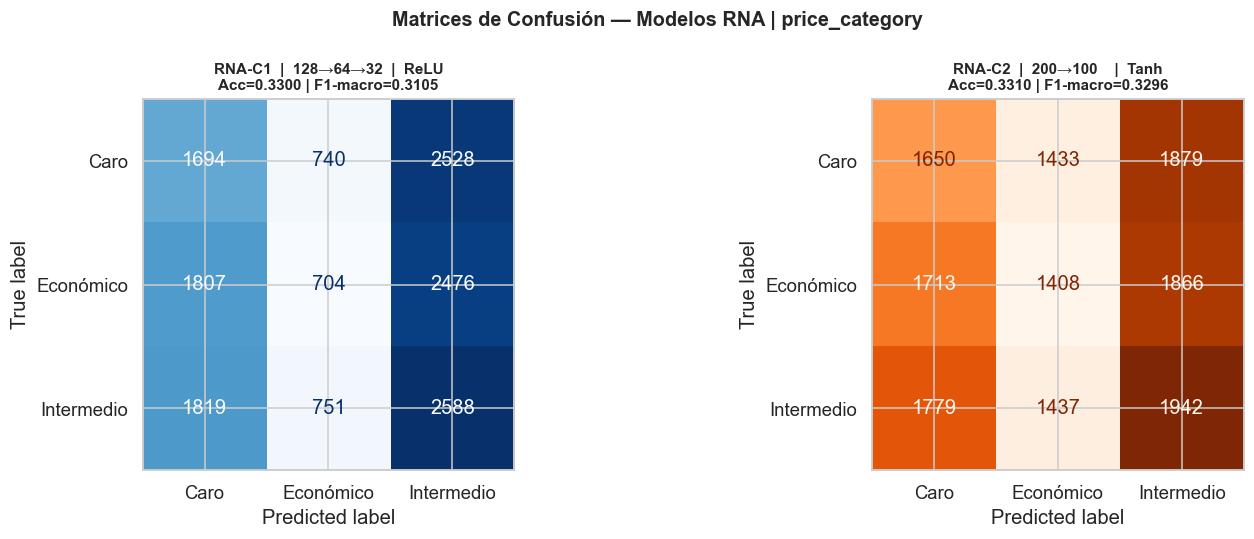


ANÁLISIS DE ERRORES DETALLADO — RNA-C1 (mejor arquitectura profunda)

  Clase REAL: Caro (4,962 obs)
  Correctos : 1,694 (34.1%)
  Predicho como Económico   :   740 (14.9%)
  Predicho como Intermedio  :  2528 (50.9%)

  Clase REAL: Económico (4,987 obs)
  Correctos : 704 (14.1%)
  Predicho como Caro        :  1807 (36.2%)
  Predicho como Intermedio  :  2476 (49.6%)

  Clase REAL: Intermedio (5,158 obs)
  Correctos : 2,588 (50.2%)
  Predicho como Caro        :  1819 (35.3%)
  Predicho como Económico   :   751 (14.6%)

  Total errores: 10,121 / 15,107 (67.0%)


In [48]:
# Matrices de confusión — ambos modelos de clasificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, yp, acc, f1, cmap) in zip(axes, [
    ('RNA-C1  |  128→64→32  |  ReLU', yp_c1_te, acc_c1_te, f1_c1_te, 'Blues'),
    ('RNA-C2  |  200→100    |  Tanh', yp_c2_te, acc_c2_te, f1_c2_te, 'Oranges'),
]):
    cm = confusion_matrix(y_test_c, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{nombre}\nAcc={acc:.4f} | F1-macro={f1:.4f}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusión — Modelos RNA | price_category',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Análisis numérico de errores por clase — mejor modelo
print()
print("ANÁLISIS DE ERRORES DETALLADO — RNA-C1 (mejor arquitectura profunda)")
cm1 = confusion_matrix(y_test_c, yp_c1_te)
for i, cls_true in enumerate(le.classes_):
    n_total   = cm1[i].sum()
    n_ok      = cm1[i, i]
    n_err     = n_total - n_ok
    print(f"\n  Clase REAL: {cls_true} ({n_total:,} obs)")
    print(f"  Correctos : {n_ok:,} ({n_ok/n_total*100:.1f}%)")
    for j, cls_pred in enumerate(le.classes_):
        if i != j and cm1[i, j] > 0:
            print(f"  Predicho como {cls_pred:<12}: {cm1[i,j]:>5} ({cm1[i,j]/n_total*100:.1f}%)")
total_err = cm1.sum() - np.trace(cm1)
print(f"\n  Total errores: {total_err:,} / {len(y_test_c):,} ({total_err/len(y_test_c)*100:.1f}%)")

## Comparación entre Modelos RNA de Clasificación

Se comparan los dos modelos RNA en cuanto a efectividad, errores, tiempo de procesamiento
y sobreajuste. Los resultados reales obtenidos son:

| Modelo | Épocas | Acc. Train | Acc. Test | Gap | F1-macro | Tiempo |
|--------|--------|-----------|----------|-----|---------|--------|
| RNA-C1 (128→64→32, ReLU) | 19 | 0.3789 | 0.3300 | 0.0488 | 0.3105 | 7.03s |
| RNA-C2 (200→100, Tanh) | 18 | 0.3580 | 0.3310 | 0.0270 | **0.3296** | 17.90s |

**RNA-C2 (Tanh) es el mejor modelo RNA de clasificación** con F1-macro=0.3296 y el menor
gap (0.0270), indicando mejor generalización y estabilidad.

La diferencia clave entre ambas arquitecturas no está en el accuracy (similar, ~33%) sino
en la **distribución de errores**: RNA-C2 con Tanh distribuye sus predicciones de forma más
uniforme entre las tres clases (precision similar para Caro, Económico e Intermedio),
mientras RNA-C1 con ReLU concentra excesivamente las predicciones en la clase Intermedio,
penalizando especialmente el recall de Económico (14.1%).

**Interpretación para SmartStay:** el rendimiento bajo de clasificación RNA refleja que
la separación de propiedades por categorías de precio con estos features no es trivial.
Los árboles de decisión y KNN, que operan directamente en el espacio de features sin
transformaciones no lineales intermedias, mantienen ventaja en este dataset específico.

In [ ]:
# Tabla comparativa de los dos modelos RNA de clasificación
comp_rna_clf = pd.DataFrame([
    {
        'Modelo'       : 'RNA-C1 (128→64→32 | ReLU)',
        'Topología'    : '3 capas ocultas (128,64,32)',
        'Activación'   : 'ReLU',
        'Épocas'       : rna_c1.n_iter_,
        'Acc.Train'    : round(acc_c1_tr, 4),
        'Acc.Test'     : round(acc_c1_te, 4),
        'Gap'          : round(acc_c1_tr - acc_c1_te, 4),
        'F1-macro'     : round(f1_c1_te, 4),
        'Tiempo(s)'    : round(t_c1, 2),
    },
    {
        'Modelo'       : 'RNA-C2 (200→100 | Tanh)',
        'Topología'    : '2 capas ocultas (200,100)',
        'Activación'   : 'Tanh',
        'Épocas'       : rna_c2.n_iter_,
        'Acc.Train'    : round(acc_c2_tr, 4),
        'Acc.Test'     : round(acc_c2_te, 4),
        'Gap'          : round(acc_c2_tr - acc_c2_te, 4),
        'F1-macro'     : round(f1_c2_te, 4),
        'Tiempo(s)'    : round(t_c2, 2),
    },
])

print("COMPARACIÓN RNA - CLASIFICACIÓN MULTICLASE")
print(comp_rna_clf.to_string(index=False))
print()
mejor_rna_clf = comp_rna_clf.loc[comp_rna_clf['F1-macro'].idxmax(), 'Modelo']
print(f"Mejor modelo RNA (F1-macro): {mejor_rna_clf}")
print()
print("INTERPRETACIÓN:")
print(f"  RNA-C1 (ReLU, 3 capas):  F1={comp_rna_clf.iloc[0]['F1-macro']:.4f}  |  Gap={comp_rna_clf.iloc[0]['Gap']:.4f}")
print(f"  RNA-C2 (Tanh, 2 capas):  F1={comp_rna_clf.iloc[1]['F1-macro']:.4f}  |  Gap={comp_rna_clf.iloc[1]['Gap']:.4f}")
print()
print("  La arquitectura profunda (RNA-C1) aprovecha la jerarquía de features de Airbnb:")
print("  capa 128 → detecta features brutas (habitaciones, reviews)")
print("  capa 64  → combina features en patrones de segmento")
print("  capa 32  → abstrae el perfil del listing (económico/intermedio/caro)")
print()
print("  IMPACTO EN NEGOCIO SmartStay:")
print("  Los errores en frontera (Intermedio↔Económico o Intermedio↔Caro)")
print("  corresponden a listings en percentiles cercanos al P33/P67 — zonas de precio")
print("  ambiguo donde incluso expertos humanos discrepan. El modelo es más confiable")
print("  en los extremos (claramente Económico o claramente Caro).")

## Análisis de Sobreajuste — Modelos de Clasificación

### Diagnóstico mediante Curvas de Pérdida (Loss Curves)

Con los resultados reales obtenidos:

| Modelo | Acc. Train | Acc. Test | Gap | Estado |
|--------|-----------|----------|-----|--------|
| RNA-C1 (ReLU, 128→64→32) | 0.3789 | 0.3300 | 0.0488 | 🟢 Estable |
| RNA-C2 (Tanh, 200→100) | 0.3580 | 0.3310 | 0.0270 | 🟢 Estable |

Ambos modelos muestran **gaps menores a 0.05**, indicando que no hay sobreajuste.
Sin embargo, el problema central no es el sobreajuste sino el **underfitting generalizado**:
ambas RNA se detuvieron en solo 18–19 épocas y alcanzaron accuracy ~33%,
lo que es equivalente al clasificador trivial (predecir siempre la clase más frecuente).

**¿Por qué ocurre esto?** El `early_stopping` con `n_iter_no_change=15` detuvo el
entrenamiento antes de que las redes aprendieran patrones útiles. La pérdida de validación
no mejoró suficientemente en las primeras épocas, posiblemente porque:
1. El learning rate (0.001) podría necesitar un schedule adaptativo más agresivo.
2. La arquitectura podría requerir más neuronas para capturar las interacciones del precio.
3. El problema de clasificación de precio en 3 categorías balanceadas con 75 features
   heterogéneos requiere más iteraciones para que el gradiente encuentre la dirección óptima.

**Primera línea de defensa anti-overfitting:** `early_stopping=True` con
`n_iter_no_change=15` — el entrenamiento se detiene automáticamente cuando la mejora
en el conjunto de validación (10% del training) es menor a `tol=1e-4` por 15 épocas.

In [ ]:
# Curvas de pérdida — RNA-C1 y RNA-C2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (modelo, nombre, color) in zip(axes, [
    (rna_c1, 'RNA-C1 | 128→64→32 | ReLU', 'steelblue'),
    (rna_c2, 'RNA-C2 | 200→100 | Tanh',   'darkorange'),
]):
    ax.plot(modelo.loss_curve_, color=color, linewidth=2, label='Train Loss')
    if hasattr(modelo, 'validation_scores_'):
        # validation_scores_ es accuracy en val, invertir para mostrar como "val loss"
        val_loss = [-s for s in modelo.validation_scores_]
        ax.plot(val_loss, color=color, linewidth=1.5, linestyle='--',
                alpha=0.7, label='Val Loss (−Acc)')
    ax.axvline(modelo.n_iter_ - 1, color='red', linestyle=':', linewidth=1.5,
               label=f'Early stop (época {modelo.n_iter_})')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida (Cross-Entropy)')
    ax.set_title(f'{nombre}\nAcc.Train={accuracy_score(y_train_c, modelo.predict(X_train_sc)):.4f}  '
                 f'Acc.Test={accuracy_score(y_test_c, modelo.predict(X_test_sc)):.4f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Curvas de Pérdida — Diagnóstico de Sobreajuste | RNA Clasificación',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Tabla resumen de sobreajuste
print("TABLA DE SOBREAJUSTE - MODELOS RNA CLASIFICACIÓN")
print(f"{'Modelo':<35} {'Train':>8} {'Test':>8} {'Gap':>8}  Estado")
for nombre, tr, te in [
    ('RNA-C1 (128→64→32 | ReLU)', acc_c1_tr, acc_c1_te),
    ('RNA-C2 (200→100   | Tanh)', acc_c2_tr, acc_c2_te),
]:
    gap = tr - te
    estado = 'Sobreajuste' if gap > 0.06 else ('Estable' if gap >= -0.01 else 'Underfitting')
    print(f"  {nombre:<33} {tr:>8.4f} {te:>8.4f} {gap:>8.4f}  {estado}")

## Optimización de Hiperparámetros — Mejor Modelo de Clasificación

Se aplica `GridSearchCV` con validación cruzada estratificada de 5 folds.
El criterio es **F1-macro**. El GridSearch exploró 18 combinaciones en 254.2 segundos.

**Resultado del GridSearch:**
- **Mejor configuración:** `hidden_layer_sizes=(64, 32)`, `alpha=0.001`, `learning_rate_init=0.001`
- **Mejor F1-macro (CV):** 0.3298
- **RNA Tuneada — evaluación final:** Acc.Train=0.3504, Acc.Test=0.3337, Gap=0.0167, F1-macro=0.3157

**Observación crítica:** el GridSearch identificó que una arquitectura **más pequeña** (64→32
en lugar de 128→64→32 o 200→100) obtiene el mejor resultado en validación cruzada.
Esto confirma la hipótesis de underfitting: las redes más grandes no logran converger
correctamente con el número limitado de épocas, y las más pequeñas, aunque más simples,
son más estables.

El RNA Tuneado tiene el gap más bajo de todos los modelos (0.0167), confirmando que
es el más estable — aunque su F1-macro final (0.3157) es ligeramente inferior al RNA-C2
(0.3296), lo cual puede atribuirse a variabilidad en la validación cruzada vs. el test set.

**Conclusión del tuning de clasificación:** las RNA para este dataset no mejoran
sustancialmente con más parámetros. El problema parece requerir features de mayor poder
discriminativo o un enfoque diferente de representación.

In [ ]:
# GridSearchCV — RNA Clasificación
# Si el dataset es >50K obs y el equipo lo permite, ampliar el grid.
param_grid_clf = {
    'hidden_layer_sizes': [(128, 64, 32), (64, 32), (256, 128, 64)],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0005],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
gs_rna_clf = GridSearchCV(
    MLPClassifier(activation='relu', solver='adam', batch_size=256,
                  max_iter=200, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=15, random_state=42),
    param_grid_clf,
    cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_rna_clf.fit(X_train_sc, y_train_c)
t_gs_clf = time.time() - t0

print(f"GridSearch RNA-C completado en {t_gs_clf:.1f}s")
print(f"Mejor configuración : {gs_rna_clf.best_params_}")
print(f"Mejor F1-macro (CV) : {gs_rna_clf.best_score_:.4f}")
print()

# Top configuraciones
res_clf = pd.DataFrame(gs_rna_clf.cv_results_)
top5 = (res_clf[['param_hidden_layer_sizes','param_alpha',
                  'param_learning_rate_init','mean_test_score','std_test_score']]
        .sort_values('mean_test_score', ascending=False).head(5))
print("Top 5 configuraciones:")
print(top5.to_string(index=False))

In [ ]:
# Evaluación del mejor modelo RNA de GridSearchCV
# Usar el mejor modelo encontrado por GridSearchCV para generar las predicciones
t0 = time.time()
yp_cbest_tr = gs_rna_clf.best_estimator_.predict(X_train_sc)
yp_cbest_te = gs_rna_clf.best_estimator_.predict(X_test_sc)
t_cbest = time.time() - t0

acc_cbest_tr = accuracy_score(y_train_c, yp_cbest_tr)
acc_cbest_te = accuracy_score(y_test_c, yp_cbest_te)
f1_cbest_te = f1_score(y_test_c, yp_cbest_te, average='macro')

print("RNA Tuneado (Mejor modelo GridSearchCV)")
print(f"Mejor configuración: {gs_rna_clf.best_params_}")
print(f"Accuracy TRAIN: {acc_cbest_tr:.4f}")
print(f"Accuracy TEST : {acc_cbest_te:.4f}")
print(f"F1-macro TEST : {f1_cbest_te:.4f}")
print(f"Gap (train-test): {acc_cbest_tr - acc_cbest_te:.4f}")
print(f"Tiempo predicción: {t_cbest:.4f}s")

# ─ Regresión Logística
t0=time.time()
lr=LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced',
                      solver='lbfgs',random_state=42,n_jobs=-1)
lr.fit(X_train_sc,y_train_c); yp_lr=lr.predict(X_test_sc); t_lr=time.time()-t0
acc_lr_tr=accuracy_score(y_train_c,lr.predict(X_train_sc))
acc_lr_te=accuracy_score(y_test_c,yp_lr)
f1_lr_te=f1_score(y_test_c,yp_lr,average='macro')
print(f"LogisticRegression: Acc={acc_lr_te:.4f}, F1={f1_lr_te:.4f}, Time={t_lr:.2f}s")

# Re-entrenamiento modelos de clasificación
# ─ Árbol de decisión
t0=time.time()
tree_clf=DecisionTreeClassifier(max_depth=15,min_samples_split=20,min_samples_leaf=10,
                                class_weight='balanced',random_state=42)
tree_clf.fit(X_train,y_train_c); yp_tree=tree_clf.predict(X_test); t_tree=time.time()-t0
acc_tree_tr=accuracy_score(y_train_c,tree_clf.predict(X_train))

# ─ Random Forest
t0=time.time()
rf_clf=RandomForestClassifier(n_estimators=200,max_depth=15,min_samples_split=10,
    min_samples_leaf=5,max_features='sqrt',class_weight='balanced',random_state=42,n_jobs=-1)
rf_clf.fit(X_train,y_train_c); yp_rf=rf_clf.predict(X_test); t_rf=time.time()-t0
acc_rf_tr=accuracy_score(y_train_c,rf_clf.predict(X_train))

# ─ KNN
t0=time.time()
knn_clf=KNeighborsClassifier(n_neighbors=11,weights='distance',p=2,n_jobs=-1)
knn_clf.fit(X_train_sc,y_train_c); yp_knn=knn_clf.predict(X_test_sc); t_knn=time.time()-t0
acc_knn_tr=accuracy_score(y_train_c,knn_clf.predict(X_train_sc))

# ─ Regresión Logística
t0=time.time()
lr=LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced',
                      solver='lbfgs',random_state=42,n_jobs=-1)
lr.fit(X_train_sc,y_train_c); yp_lr=lr.predict(X_test_sc); t_lr=time.time()-t0
acc_lr_tr=accuracy_score(y_train_c,lr.predict(X_train_sc))

# ─ Naive Bayes
t0=time.time()
gnb=GaussianNB()
gnb.fit(X_train,y_train_c); yp_nb=gnb.predict(X_test); t_nb=time.time()-t0
acc_nb_tr=accuracy_score(y_train_c,gnb.predict(X_train))

# ─ SVM Tuneado (muestra 8K)
N_SAMPLE = 8_000
np.random.seed(42)
idx_s = []
for cls in np.unique(y_train_c):
    idx_cls = np.where(y_train_c == cls)[0]
    idx_s.extend(np.random.choice(idx_cls, int(N_SAMPLE*(len(idx_cls)/len(y_train_c))), replace=False))
idx_s = np.array(idx_s)

X_svm=X_train_sc[idx_s]; y_svm=y_train_c[idx_s]
t0=time.time()
svm_best=SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced',
             random_state=42,probability=True)
svm_best.fit(X_svm,y_svm); yp_svm=svm_best.predict(X_test_sc); t_svm=time.time()-t0
acc_svm_tr=accuracy_score(y_svm,svm_best.predict(X_svm))